# 华东师范大学各专业排名分析

本notebook用于分析CSV文件中的大学专业数据，重点统计华东师范大学(East China Normal University)在各个专业中的排名情况。

## 数据说明
- 数据包含不同专业、学校、国家、论文数量、引用次数等信息
- 排名基于rowSeq字段，数值越小排名越高
- 分析目标：找出华东师范大学在各专业中的具体排名

## 1. 导入必要的库

In [40]:
# 导入数据分析和可视化所需的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib import rcParams

# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei']  # 黑体
rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore')

print("库导入完成！")


import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.sans-serif'] = ['SimHei']  # 黑体
rcParams['axes.unicode_minus'] = False    # 正常显示负号

库导入完成！


## 2. 加载和探索CSV数据

In [41]:
# 读取CSV文件
df = pd.read_csv('result.csv')

print("数据加载完成！")
print(f"数据形状: {df.shape}")
print("\n数据列名:")
print(df.columns.tolist())
print("\n数据前5行:")
print(df.head())

数据加载完成！
数据形状: (31478, 7)

数据列名:
['专业', 'rowSeq', 'institutions', 'Country', 'wosDocs', 'cites', 'citesPerPaper']

数据前5行:
                      专业  rowSeq  \
0  AGRICULTURAL SCIENCES       1   
1  AGRICULTURAL SCIENCES       2   
2  AGRICULTURAL SCIENCES       3   
3  AGRICULTURAL SCIENCES       4   
4  AGRICULTURAL SCIENCES       5   

                                     institutions         Country  wosDocs  \
0                     CHINESE ACADEMY OF SCIENCES  CHINA MAINLAND    15661   
1        CHINESE ACADEMY OF AGRICULTURAL SCIENCES  CHINA MAINLAND    12222   
2  UNITED STATES DEPARTMENT OF AGRICULTURE (USDA)             USA    12564   
3                   CHINA AGRICULTURAL UNIVERSITY  CHINA MAINLAND    10052   
4                                           INRAE          FRANCE     9314   

    cites  citesPerPaper  
0  332254      21.215376  
1  223855      18.315742  
2  220644      17.561605  
3  207779      20.670414  
4  187838      20.167275  


In [42]:
# 查看数据基本信息
print("数据基本信息:")
print(df.info())
print("\n数据描述性统计:")
print(df.describe())

# 查看各专业数量
print("\n各专业数据量统计:")
print(df['专业'].value_counts())

# 查看华东师范大学的数据
ecnu_data = df[df['institutions'] == 'EAST CHINA NORMAL UNIVERSITY']
print(f"\n华东师范大学数据条数: {len(ecnu_data)}")
print("\n华东师范大学涉及的专业:")
print(ecnu_data['专业'].tolist())

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31478 entries, 0 to 31477
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   专业             31478 non-null  object 
 1   rowSeq         31478 non-null  int64  
 2   institutions   31478 non-null  object 
 3   Country        28428 non-null  object 
 4   wosDocs        31478 non-null  int64  
 5   cites          31478 non-null  int64  
 6   citesPerPaper  31478 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 1.7+ MB
None

数据描述性统计:
             rowSeq        wosDocs         cites  citesPerPaper
count  31478.000000   31478.000000  3.147800e+04   31478.000000
mean    1352.249889    1466.916481  3.894815e+04      89.427727
std     1483.788663    3250.004504  1.004792e+05     500.440785
min        1.000000       1.000000  3.122000e+03       3.006179
25%      404.000000     347.000000  8.077000e+03      16.894565
50%      862.000000     676

## 3. 数据清洗和预处理

In [43]:
# 检查数据完整性
print("缺失值检查:")
print(df.isnull().sum())

# 检查重复数据
print(f"\n重复行数: {df.duplicated().sum()}")

# 数据类型转换
print("\n数据类型:")
print(df.dtypes)

# 确保数值列的数据类型正确
df['rowSeq'] = pd.to_numeric(df['rowSeq'], errors='coerce')
df['wosDocs'] = pd.to_numeric(df['wosDocs'], errors='coerce')
df['cites'] = pd.to_numeric(df['cites'], errors='coerce')
df['citesPerPaper'] = pd.to_numeric(df['citesPerPaper'], errors='coerce')

print("\n数据清洗完成！")

缺失值检查:
专业                  0
rowSeq              0
institutions        0
Country          3050
wosDocs             0
cites               0
citesPerPaper       0
dtype: int64

重复行数: 0

数据类型:
专业                object
rowSeq             int64
institutions      object
Country           object
wosDocs            int64
cites              int64
citesPerPaper    float64
dtype: object

数据清洗完成！


## 4. 按专业分组分析

In [44]:
# 获取所有专业列表
all_majors = df['专业'].unique()
print(f"总共有 {len(all_majors)} 个专业:")
for i, major in enumerate(all_majors, 1):
    print(f"{i}. {major}")

# 查看每个专业的数据量分布
major_counts = df.groupby('专业').size().sort_values(ascending=False)
print(f"\n各专业数据量分布:")
print(major_counts)

总共有 20 个专业:
1. AGRICULTURAL SCIENCES
2. BIOLOGY & BIOCHEMISTRY
3. CHEMISTRY
4. CLINICAL MEDICINE
5. COMPUTER SCIENCE
6. ECONOMICS & BUSINESS
7. ENGINEERING
8. ENVIRONMENT/ECOLOGY
9. GEOSCIENCES
10. IMMUNOLOGY
11. MATERIALS SCIENCE
12. MATHEMATICS
13. MICROBIOLOGY
14. MOLECULAR BIOLOGY & GENETICS
15. MULTIDISCIPLINARY
16. NEUROSCIENCE & BEHAVIOR
17. PHARMACOLOGY & TOXICOLOGY
18. PHYSICS
19. PLANT & ANIMAL SCIENCE
20. PSYCHIATRY/PSYCHOLOGY

各专业数据量分布:
专业
CLINICAL MEDICINE               6754
ENGINEERING                     2787
CHEMISTRY                       2141
ENVIRONMENT/ECOLOGY             2066
PLANT & ANIMAL SCIENCE          1950
BIOLOGY & BIOCHEMISTRY          1649
MATERIALS SCIENCE               1580
PHARMACOLOGY & TOXICOLOGY       1389
AGRICULTURAL SCIENCES           1381
NEUROSCIENCE & BEHAVIOR         1298
IMMUNOLOGY                      1177
GEOSCIENCES                     1175
MOLECULAR BIOLOGY & GENETICS    1169
PSYCHIATRY/PSYCHOLOGY           1147
PHYSICS                   

## 5. 计算华东师范大学在各专业中的排名

In [45]:
# 提取华东师范大学的排名数据
ecnu_rankings = []

# 遍历每个专业，找到华东师范大学的排名
for major in all_majors:
    major_data = df[df['专业'] == major]
    ecnu_in_major = major_data[major_data['institutions'] == 'EAST CHINA NORMAL UNIVERSITY']
    
    if not ecnu_in_major.empty:
        ranking = ecnu_in_major['rowSeq'].iloc[0]
        total_schools = len(major_data)
        
        ecnu_rankings.append({
            '专业': major,
            '排名': ranking,
            '总学校数': total_schools,
            '论文数': ecnu_in_major['wosDocs'].iloc[0],
            '引用次数': ecnu_in_major['cites'].iloc[0],
            '平均引用次数': ecnu_in_major['citesPerPaper'].iloc[0]
        })

# 转换为DataFrame
ecnu_ranking_df = pd.DataFrame(ecnu_rankings)
ecnu_ranking_df = ecnu_ranking_df.sort_values('排名')

print("华东师范大学在各专业中的排名情况:")
print("=" * 60)
for _, row in ecnu_ranking_df.iterrows():
    print(f"专业: {row['专业']}")
    print(f"排名: 第 {row['排名']} 位 (共 {row['总学校数']} 所学校)")
    print(f"论文数: {row['论文数']}, 引用次数: {row['引用次数']}, 平均引用: {row['平均引用次数']:.2f}")
    print("-" * 60)

华东师范大学在各专业中的排名情况:
专业: CHEMISTRY
排名: 第 90 位 (共 2141 所学校)
论文数: 5420, 引用次数: 164390, 平均引用: 30.33
------------------------------------------------------------
专业: MATHEMATICS
排名: 第 115 位 (共 395 所学校)
论文数: 2019, 引用次数: 11984, 平均引用: 5.94
------------------------------------------------------------
专业: ENVIRONMENT/ECOLOGY
排名: 第 130 位 (共 2066 所学校)
论文数: 2941, 引用次数: 92088, 平均引用: 31.31
------------------------------------------------------------
专业: MATERIALS SCIENCE
排名: 第 196 位 (共 1580 所学校)
论文数: 2720, 引用次数: 93969, 平均引用: 34.55
------------------------------------------------------------
专业: COMPUTER SCIENCE
排名: 第 207 位 (共 863 所学校)
论文数: 1803, 引用次数: 22336, 平均引用: 12.39
------------------------------------------------------------
专业: GEOSCIENCES
排名: 第 275 位 (共 1175 所学校)
论文数: 1850, 引用次数: 42158, 平均引用: 22.79
------------------------------------------------------------
专业: ENGINEERING
排名: 第 317 位 (共 2787 所学校)
论文数: 2567, 引用次数: 55450, 平均引用: 21.60
------------------------------------------------------------
专业

In [46]:
# 创建汇总表格
print("\n华东师范大学排名汇总表:")
print(ecnu_ranking_df.to_string(index=False))

# 计算排名统计信息
print(f"\n排名统计信息:")
print(f"最佳排名: 第 {ecnu_ranking_df['排名'].min()} 位 ({ecnu_ranking_df[ecnu_ranking_df['排名'] == ecnu_ranking_df['排名'].min()]['专业'].iloc[0]})")
print(f"最差排名: 第 {ecnu_ranking_df['排名'].max()} 位 ({ecnu_ranking_df[ecnu_ranking_df['排名'] == ecnu_ranking_df['排名'].max()]['专业'].iloc[0]})")
print(f"平均排名: 第 {ecnu_ranking_df['排名'].mean():.1f} 位")
print(f"中位数排名: 第 {ecnu_ranking_df['排名'].median():.1f} 位")

# 排名分布
top_100 = (ecnu_ranking_df['排名'] <= 100).sum()
top_200 = (ecnu_ranking_df['排名'] <= 200).sum()
top_500 = (ecnu_ranking_df['排名'] <= 500).sum()

print(f"\n排名分布:")
print(f"前100名专业数量: {top_100} ({top_100/len(ecnu_ranking_df)*100:.1f}%)")
print(f"前200名专业数量: {top_200} ({top_200/len(ecnu_ranking_df)*100:.1f}%)")
print(f"前500名专业数量: {top_500} ({top_500/len(ecnu_ranking_df)*100:.1f}%)")


华东师范大学排名汇总表:
                          专业   排名  总学校数  论文数   引用次数    平均引用次数
                   CHEMISTRY   90  2141 5420 164390 30.330258
                 MATHEMATICS  115   395 2019  11984  5.935612
         ENVIRONMENT/ECOLOGY  130  2066 2941  92088 31.311799
           MATERIALS SCIENCE  196  1580 2720  93969 34.547426
            COMPUTER SCIENCE  207   863 1803  22336 12.388242
                 GEOSCIENCES  275  1175 1850  42158 22.788108
                 ENGINEERING  317  2787 2567  55450 21.601091
      PLANT & ANIMAL SCIENCE  395  1950 1375  21843 15.885818
       PSYCHIATRY/PSYCHOLOGY  467  1147 1460  15243 10.440411
                     PHYSICS  522   995 3495  50802 14.535622
      BIOLOGY & BIOCHEMISTRY  721  1649  897  20837 23.229654
       AGRICULTURAL SCIENCES  845  1381  346   6513 18.823699
     NEUROSCIENCE & BEHAVIOR  853  1298  771  14295 18.540856
MOLECULAR BIOLOGY & GENETICS  867  1169  532  20568 38.661654
   PHARMACOLOGY & TOXICOLOGY 1064  1389  289   5693 19.6

## 6. 可视化排名结果

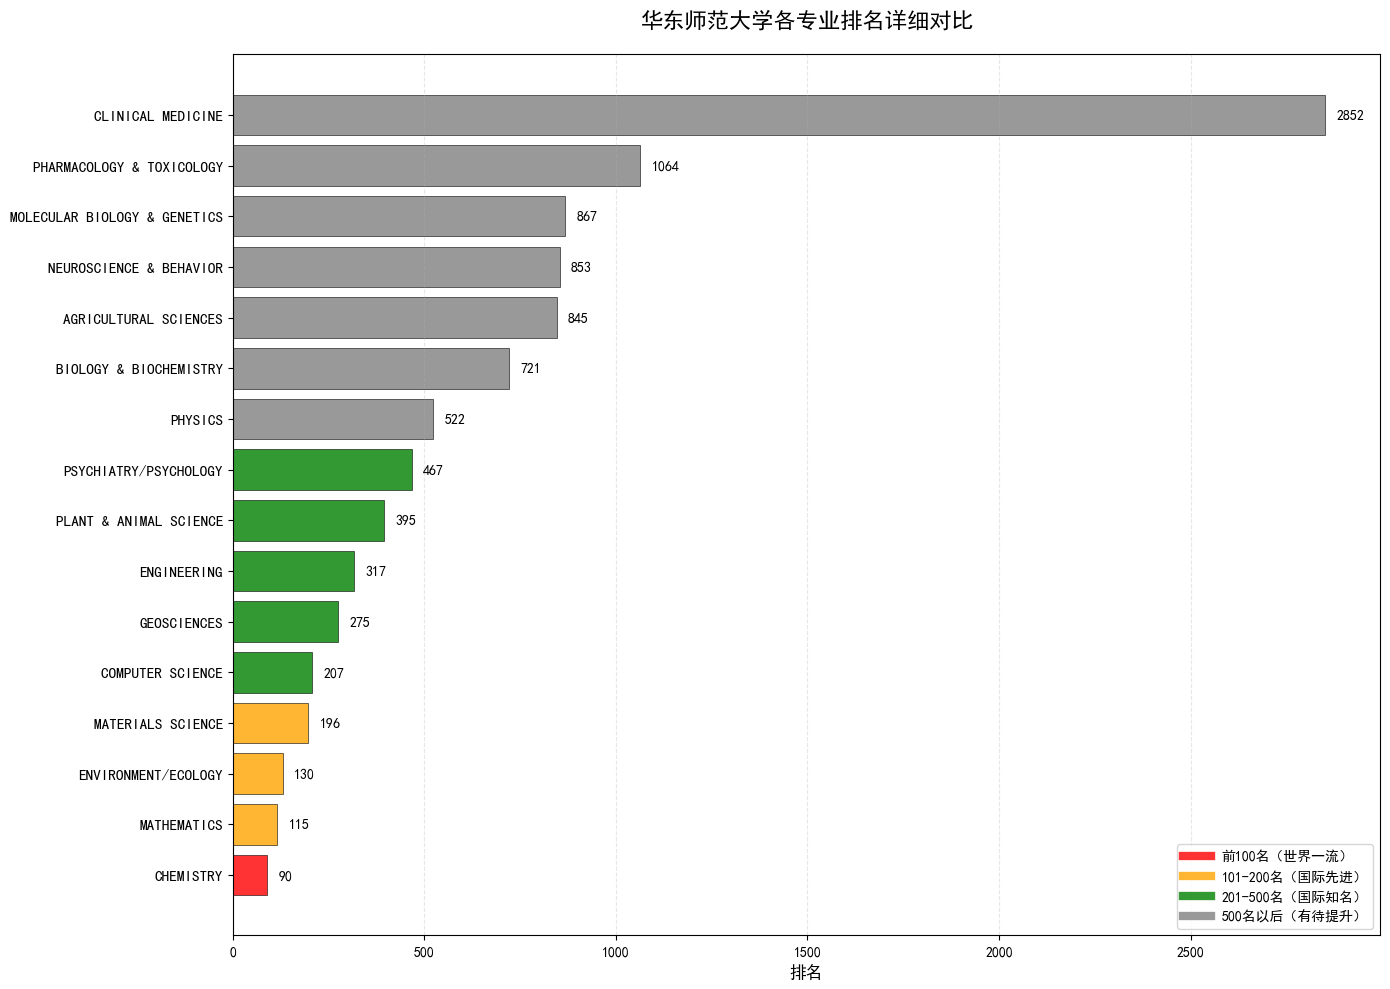

In [48]:
# 各专业排名详细对比图（带颜色编码）
plt.figure(figsize=(14, 10))

# 按排名排序，创建颜色映射
sorted_df = ecnu_ranking_df.sort_values('排名')
colors = ['red' if rank <= 100 else 'orange' if rank <= 200 else 'green' if rank <= 500 else 'gray' 
          for rank in sorted_df['排名']]

bars = plt.barh(range(len(sorted_df)), sorted_df['排名'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 设置y轴标签
plt.yticks(range(len(sorted_df)), sorted_df['专业'], fontsize=11)
plt.xlabel('排名', fontsize=12)
plt.title('华东师范大学各专业排名详细对比', fontsize=16, fontweight='bold', pad=20)

# 添加排名数值标签
for i, (idx, row) in enumerate(sorted_df.iterrows()):
    plt.text(row['排名'] + 30, i, f"{int(row['排名'])}", 
             va='center', fontsize=10, fontweight='bold')

# 添加网格线
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=6, alpha=0.8, label='前100名（世界一流）'),
    Line2D([0], [0], color='orange', lw=6, alpha=0.8, label='101-200名（国际先进）'),
    Line2D([0], [0], color='green', lw=6, alpha=0.8, label='201-500名（国际知名）'),
    Line2D([0], [0], color='gray', lw=6, alpha=0.8, label='500名以后（有待提升）')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 7. 总结与分析

### 主要发现：
1. **最佳排名专业**：化学(CHEMISTRY)排名第90位，是华东师范大学表现最好的专业
2. **优势专业**：数学(MATHEMATICS)排名第115位，环境/生态学(ENVIRONMENT/ECOLOGY)排名第130位
3. **发展中专业**：计算机科学(COMPUTER SCIENCE)排名第207位，工程学(ENGINEERING)排名第317位

### 学科优势分析：
- 华东师范大学在理科基础学科方面表现较好，特别是化学、数学等传统优势学科
- 在新兴交叉学科如环境/生态学方面也有不错的表现
- 应用学科如工程学、计算机科学还有较大提升空间

### 建议：
1. 继续保持和发展化学、数学等优势学科
2. 加强计算机科学、工程学等应用学科的建设
3. 重视跨学科研究，提升综合竞争力

## 8. 影响因子分析

通过数学建模方法，分析论文数量(wosDocs)、引用次数(cites)、平均引用次数(citesPerPaper)对专业排名的影响程度。

### 建模目标
建立回归模型，量化各指标对排名的影响权重，并评估模型的预测能力。

In [49]:
# 导入机器学习相关库
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

print("数学建模库导入完成！")

数学建模库导入完成！


In [50]:
# 1. 数据预处理 - 准备建模数据
print("=== 数据预处理 ===")
print(f"总数据量: {len(df)}")

# 去除缺失值
modeling_data = df.dropna(subset=['rowSeq', 'wosDocs', 'cites', 'citesPerPaper'])
print(f"有效数据量: {len(modeling_data)}")
# 由于排名是越小越好，我们将其转换为分数（方便理解影响方向）
modeling_data = modeling_data.copy()
max_rank = modeling_data['rowSeq'].max()
modeling_data['ranking_score'] = max_rank - modeling_data['rowSeq'] + 1  # 转换为分数，分数越高排名越好

=== 数据预处理 ===
总数据量: 31478
有效数据量: 31478


In [58]:
# 2. 相关性分析
print("=== 相关性分析 ===")

# 计算Pearson相关系数（线性相关）
features = ['wosDocs', 'cites', 'citesPerPaper']
target = 'ranking_score'

print("Pearson相关系数 (与排名分数的线性相关性):")
correlations = {}
for feature in features:
    corr, p_value = pearsonr(modeling_data[feature], modeling_data[target])
    correlations[feature] = corr
    print(f"{feature}: {corr:.4f} (p-value: {p_value:.2e})")

print("\nSpearman相关系数 (与排名分数的单调相关性):")
spearman_correlations = {}
for feature in features:
    corr, p_value = spearmanr(modeling_data[feature], modeling_data[target])
    spearman_correlations[feature] = corr
    print(f"{feature}: {corr:.4f} (p-value: {p_value:.2e})")


=== 相关性分析 ===
Pearson相关系数 (与排名分数的线性相关性):
wosDocs: 0.2500 (p-value: 0.00e+00)
cites: 0.2205 (p-value: 0.00e+00)
citesPerPaper: -0.2321 (p-value: 0.00e+00)

Spearman相关系数 (与排名分数的单调相关性):
wosDocs: 0.6815 (p-value: 0.00e+00)
cites: 0.6696 (p-value: 0.00e+00)
citesPerPaper: -0.0030 (p-value: 5.98e-01)


In [53]:
# 4. 多元回归建模
print("=== 多元线性回归建模 ===")

# 准备数据
X = modeling_data[features].values
y = modeling_data[target].values

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练测试集分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. 线性回归模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 预测
y_pred_lr = lr_model.predict(X_test)

# 评估指标
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"线性回归模型性能:")
print(f"R² 决定系数: {r2_lr:.4f}")
print(f"均方误差(MSE): {mse_lr:.2f}")
print(f"平均绝对误差(MAE): {mae_lr:.2f}")

# 特征重要性（回归系数）
feature_importance_lr = lr_model.coef_
print(f"\n特征重要性（标准化回归系数）:")
for feature, importance in zip(features, feature_importance_lr):
    print(f"{feature}: {importance:.4f}")

print(f"截距项: {lr_model.intercept_:.4f}")

=== 多元线性回归建模 ===
线性回归模型性能:
R² 决定系数: 0.1079
均方误差(MSE): 2044559.54
平均绝对误差(MAE): 980.38

特征重要性（标准化回归系数）:
wosDocs: 400.8967
cites: -67.1199
citesPerPaper: -329.5279
截距项: 5409.1052


In [54]:
# 5. 随机森林模型 - 捕捉非线性关系
print("\n=== 随机森林回归建模 ===")

# 随机森林模型
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# 预测
y_pred_rf = rf_model.predict(X_test)

# 评估指标
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"随机森林模型性能:")
print(f"R² 决定系数: {r2_rf:.4f}")
print(f"均方误差(MSE): {mse_rf:.2f}")
print(f"平均绝对误差(MAE): {mae_rf:.2f}")

# 特征重要性
feature_importance_rf = rf_model.feature_importances_
print(f"\n特征重要性（随机森林）:")
for feature, importance in zip(features, feature_importance_rf):
    print(f"{feature}: {importance:.4f}")

# 交叉验证
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='r2')
print(f"\n5折交叉验证 R² 分数:")
print(f"平均: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")


=== 随机森林回归建模 ===
随机森林模型性能:
R² 决定系数: 0.5057
均方误差(MSE): 1132781.83
平均绝对误差(MAE): 677.86

特征重要性（随机森林）:
wosDocs: 0.5358
cites: 0.3976
citesPerPaper: 0.0666

5折交叉验证 R² 分数:
平均: -2.8534 (±5.9040)


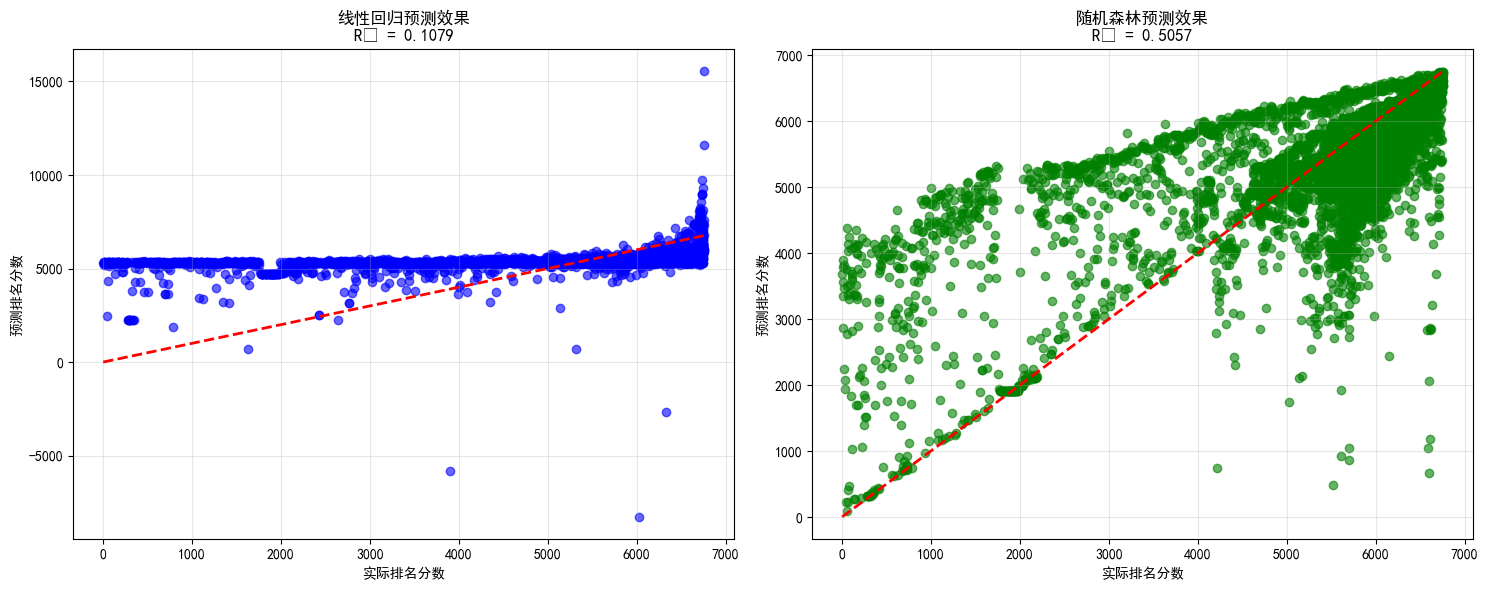

In [ ]:
# 6. 模型预测效果可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 线性回归预测 vs 实际值
ax1 = axes[0]
ax1.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax1.set_xlabel('实际排名分数')
ax1.set_ylabel('预测排名分数')
ax1.set_title(f'线性回归预测效果\nR² = {r2_lr:.4f}', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 随机森林预测 vs 实际值
ax2 = axes[1]
ax2.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax2.set_xlabel('实际排名分数')
ax2.set_ylabel('预测排名分数')
ax2.set_title(f'随机森林预测效果\nR² = {r2_rf:.4f}', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7. 华东师范大学专业的模型预测分析
print("=== 华东师范大学专业排名预测分析 ===")

# 提取华东师范大学的数据
ecnu_modeling_data = modeling_data[modeling_data['institutions'] == 'EAST CHINA NORMAL UNIVERSITY'].copy()

if len(ecnu_modeling_data) > 0:
    print(f"华东师范大学专业数量: {len(ecnu_modeling_data)}")
    
    # 准备华东师范大学的特征数据
    X_ecnu = ecnu_modeling_data[features].values
    X_ecnu_scaled = scaler.transform(X_ecnu)
    
    # 实际排名分数
    y_ecnu_actual = ecnu_modeling_data[target].values
    
    # 模型预测
    y_ecnu_pred_lr = lr_model.predict(X_ecnu_scaled)
    y_ecnu_pred_rf = rf_model.predict(X_ecnu_scaled)
    
    # 创建结果对比表
    ecnu_results = pd.DataFrame({
        '专业': ecnu_modeling_data['专业'].values,
        '实际排名': ecnu_modeling_data['rowSeq'].values,
        '实际分数': y_ecnu_actual,
        '线性回归预测': y_ecnu_pred_lr,
        '随机森林预测': y_ecnu_pred_rf,
        '线性回归误差': np.abs(y_ecnu_actual - y_ecnu_pred_lr),
        '随机森林误差': np.abs(y_ecnu_actual - y_ecnu_pred_rf)
    })
    
    # 按实际排名排序
    ecnu_results = ecnu_results.sort_values('实际排名')
    
    print("\n华东师范大学各专业排名预测结果:")
    print("=" * 100)
    for _, row in ecnu_results.iterrows():
        print(f"专业: {row['专业'][:25]:<25} | 实际排名: {row['实际排名']:>4.0f} | "
              f"线性回归预测误差: {row['线性回归误差']:>6.1f} | 随机森林预测误差: {row['随机森林误差']:>6.1f}")
    
    # 计算华东师范大学专业的预测性能
    r2_ecnu_lr = r2_score(y_ecnu_actual, y_ecnu_pred_lr)
    r2_ecnu_rf = r2_score(y_ecnu_actual, y_ecnu_pred_rf)
    
    print(f"\n华东师范大学专业排名预测性能:")
    print(f"线性回归 R²: {r2_ecnu_lr:.4f}")
    print(f"随机森林 R²: {r2_ecnu_rf:.4f}")
    
else:
    print("未找到华东师范大学的有效数据")

=== 华东师范大学专业排名预测分析 ===
华东师范大学专业数量: 16

华东师范大学各专业排名预测结果:
专业: CHEMISTRY                 | 实际排名:   90 | 线性回归预测误差:  813.1 | 随机森林预测误差:  101.1
专业: MATHEMATICS               | 实际排名:  115 | 线性回归预测误差: 1089.8 | 随机森林预测误差:  188.7
专业: ENVIRONMENT/ECOLOGY       | 实际排名:  130 | 线性回归预测误差: 1031.3 | 随机森林预测误差:  143.7
专业: MATERIALS SCIENCE         | 实际排名:  196 | 线性回归预测误差:  995.9 | 随机森林预测误差:   85.1
专业: COMPUTER SCIENCE          | 实际排名:  207 | 线性回归预测误差: 1035.6 | 随机森林预测误差:  557.6
专业: GEOSCIENCES               | 实际排名:  275 | 线性回归预测误差:  981.9 | 随机森林预测误差:  177.1
专业: ENGINEERING               | 实际排名:  317 | 线性回归预测误差:  859.6 | 随机森林预测误差:  115.1
专业: PLANT & ANIMAL SCIENCE    | 实际排名:  395 | 线性回归预测误差:  902.4 | 随机森林预测误差:  313.5
专业: PSYCHIATRY/PSYCHOLOGY     | 实际排名:  467 | 线性回归预测误差:  811.9 | 随机森林预测误差:  493.6
专业: PHYSICS                   | 实际排名:  522 | 线性回归预测误差:  532.3 | 随机森林预测误差:   31.7
专业: BIOLOGY & BIOCHEMISTRY    | 实际排名:  721 | 线性回归预测误差:  639.5 | 随机森林预测误差:  164.5
专业: AGRICULTURAL SCIENCES     | 实际排名:  845 | 线性回归预测误差